### Pipeline ML : Vectorisation TF-IDF + Classification


#### structure expérimentale

| Tier | Objectif | Classifier | Variable |
|------|----------|------------|----------|
| **Tier 1** | Comparaison équitable | Régression Logistique (fixe) | Représentation uniquement |
| **Tier 2** | Scénario non supervisé | Isolation Forest (fixe) | Représentation uniquement |
| **Tier 3** | Meilleure performance | Libre (RF, SVM...) | Représentation + modèle |


#### 0. Chargement des données prétraitées


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time
import os
from collections import Counter

# Chemins
OUTPUT_DIR = "../outputs/"

# Chargement des sessions enrichies
with open(os.path.join(OUTPUT_DIR, "parsed_sessions.pkl"), 'rb') as f:
    enriched_sessions = pickle.load(f)

# Chargement du split train/test partagé
with open(os.path.join(OUTPUT_DIR, "train_test_split.pkl"), 'rb') as f:
    split_data = pickle.load(f)

block_ids = split_data['block_ids']
train_idx = split_data['train_idx']
test_idx = split_data['test_idx']
labels = split_data['labels']
sequence_strings = split_data['sequence_strings']

print(f"Sessions chargées :        {len(enriched_sessions):,}")
print(f"Échantillons train :       {len(train_idx):,}")
print(f"Échantillons test :        {len(test_idx):,}")
print(f"Taux d'anomalie global :   {sum(labels)/len(labels)*100:.2f}%")


Sessions chargées :        575,061
Échantillons train :       460,048
Échantillons test :        115,013
Taux d'anomalie global :   2.93%


## 1. Vectorisation TF-IDF
Transformation des séquences d'événements en vecteurs numériques.

Chaque session est composée d'Event IDs.  
TF-IDF attribue un poids à chaque événement en fonction de :
- TF (Term Frequency) : fréquence de l'événement dans la session
- IDF (Inverse Document Frequency) : rareté de l'événement sur l'ensemble du corpus

Deux variantes :
- Unigram (A1) : chaque événement individuel est un token => capture la fréquence mais pas l'ordre
- Bigram (A2) : paires d'événements consécutifs => capture partiellement l'ordre séquentiel


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Séparation des données textuelles en train/test
X_train_text = [sequence_strings[i] for i in train_idx]
X_test_text = [sequence_strings[i] for i in test_idx]
y_train = [labels[i] for i in train_idx]
y_test = [labels[i] for i in test_idx]

print(f"Exemple de séquence (train) :")
print(f"  {X_train_text[0]}")
print(f"  Label : {'Anomaly' if y_train[0] == 1 else 'Normal'}")


Exemple de séquence (train) :
  E1 E1 E2 E1 E3 E4 E3 E4 E5 E5 E3 E4 E5 E32 E32 E32 E17 E17 E17 E17 E17 E17
  Label : Normal


### 1.1 TF-IDF Unigram (Expérience A1)


In [26]:
# Vectorisation TF-IDF unigram
# Chaque Event ID individuel est un token
tfidf_uni = TfidfVectorizer(ngram_range=(1, 1))

start = time.time()
X_train_uni = tfidf_uni.fit_transform(X_train_text)
X_test_uni = tfidf_uni.transform(X_test_text)
end= time.time()
t_tfidf_uni = end - start

print(f"=== TF-IDF Unigram ===")
print(f"Dimensions train : {X_train_uni.shape}")
print(f"Dimensions test  : {X_test_uni.shape}")
print(f"Nombre de features (vocabulaire) : {len(tfidf_uni.vocabulary_)}")
print(f"Temps de vectorisation : { t_tfidf_uni:.2f}s")
print(f"\nVocabulaire : {sorted(tfidf_uni.vocabulary_.keys())}")


=== TF-IDF Unigram ===
Dimensions train : (460048, 47)
Dimensions test  : (115013, 47)
Nombre de features (vocabulaire) : 47
Temps de vectorisation : 8.17s

Vocabulaire : ['e1', 'e10', 'e11', 'e12', 'e13', 'e14', 'e15', 'e16', 'e17', 'e18', 'e19', 'e2', 'e20', 'e21', 'e22', 'e23', 'e24', 'e25', 'e26', 'e27', 'e28', 'e29', 'e3', 'e30', 'e31', 'e32', 'e33', 'e34', 'e35', 'e36', 'e37', 'e38', 'e39', 'e4', 'e40', 'e41', 'e42', 'e43', 'e44', 'e45', 'e46', 'e47', 'e5', 'e6', 'e7', 'e8', 'e9']


### 1.2 TF-IDF Bigram (Expérience A2)


In [4]:
# Vectorisation TF-IDF avec unigrams + bigrams
tfidf_bi = TfidfVectorizer(ngram_range=(1, 2))

t_start = time.time()
X_train_bi = tfidf_bi.fit_transform(X_train_text)
X_test_bi = tfidf_bi.transform(X_test_text)
t_tfidf_bi = time.time() - t_start

print(f"=== TF-IDF Bigram ===")
print(f"Dimensions train : {X_train_bi.shape}")
print(f"Dimensions test  : {X_test_bi.shape}")
print(f"Nombre de features : {len(tfidf_bi.vocabulary_)}")
print(f"Temps de vectorisation : {t_tfidf_bi:.2f}s")
print(f"\nExemples de bigrams : {sorted(tfidf_bi.vocabulary_.keys())[:20]}")


=== TF-IDF Bigram ===
Dimensions train : (460048, 415)
Dimensions test  : (115013, 415)
Nombre de features : 415
Temps de vectorisation : 12.14s

Exemples de bigrams : ['e1', 'e1 e1', 'e1 e10', 'e1 e11', 'e1 e12', 'e1 e13', 'e1 e14', 'e1 e16', 'e1 e17', 'e1 e18', 'e1 e19', 'e1 e2', 'e1 e20', 'e1 e21', 'e1 e24', 'e1 e25', 'e1 e26', 'e1 e27', 'e1 e28', 'e1 e3']


### 1.3 Visualisation de la matrice TF-IDF
Aperçu des poids TF-IDF pour quelques sessions.


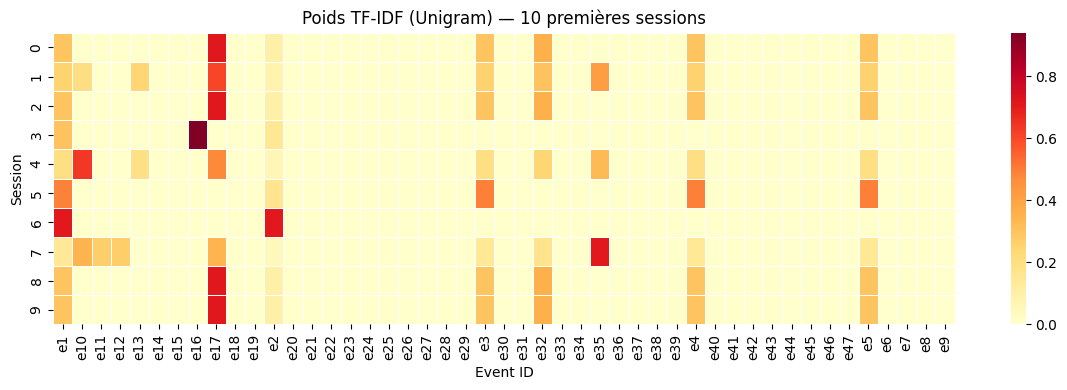

In [5]:
# Aperçu des poids TF-IDF pour les 10 premières sessions
feature_names = tfidf_uni.get_feature_names_out()
dense_sample = X_train_uni[:10].toarray()

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(dense_sample, xticklabels=feature_names, yticklabels=range(10),
            cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Poids TF-IDF (Unigram) — 10 premières sessions')
ax.set_xlabel('Event ID')
ax.set_ylabel('Session')
plt.tight_layout()
plt.show()


#### 2. Tier 1 — Comparaison équitable (Régression Logistique)
Le classifier est fixe (Régression Logistique). Seule la représentation change.  

### 2.1 Expérience A1 : TF-IDF Unigram + Régression Logistique


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Entraînement du modèle A1
lr_a1 = LogisticRegression(
    max_iter=1000,
    class_weight='balanced', # car nous avons 97% de normal et 3% de anomaly donc on ajoute le coefficient
    random_state=42,
    solver='lbfgs'
)

t_start = time.time()
lr_a1.fit(X_train_uni, y_train)
t_train_a1 = time.time() - t_start

t_start = time.time()
y_pred_a1 = lr_a1.predict(X_test_uni)
t_pred_a1 = time.time() - t_start

print("=== A1 : TF-IDF Unigram + Régression Logistique ===")
print(f"Temps d'entraînement : {t_train_a1:.2f}s")
print(f"Temps de prédiction  : {t_pred_a1:.4f}s")
print(f"\n{classification_report(y_test, y_pred_a1, target_names=['Normal', 'Anomaly'])}")


=== A1 : TF-IDF Unigram + Régression Logistique ===
Temps d'entraînement : 0.81s
Temps de prédiction  : 0.0029s

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       0.96      1.00      0.98      3368

    accuracy                           1.00    115013
   macro avg       0.98      1.00      0.99    115013
weighted avg       1.00      1.00      1.00    115013



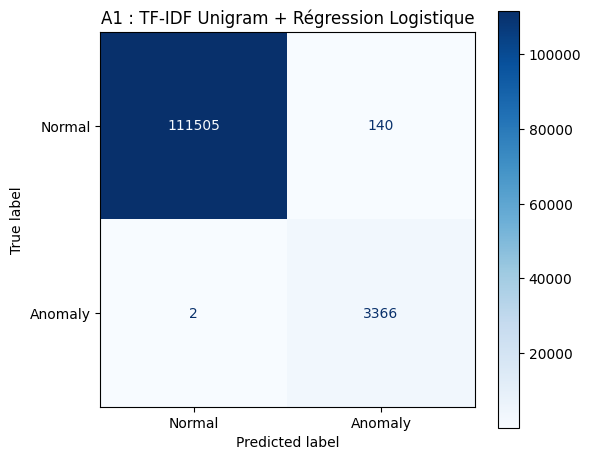

In [7]:
# Matrice de confusion — A1
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_a1,
    display_labels=['Normal', 'Anomaly'],
    cmap='Blues', ax=ax
)
ax.set_title('A1 : TF-IDF Unigram + Régression Logistique')
plt.tight_layout()
plt.show()


### 2.2 Expérience A2 : TF-IDF Bigram + Régression Logistique


In [8]:
# Entraînement du modèle A2
lr_a2 = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)

t_start = time.time()
lr_a2.fit(X_train_bi, y_train)
t_train_a2 = time.time() - t_start

t_start = time.time()
y_pred_a2 = lr_a2.predict(X_test_bi)
t_pred_a2 = time.time() - t_start

print("=== A2 : TF-IDF Bigram + Régression Logistique ===")
print(f"Temps d'entraînement : {t_train_a2:.2f}s")
print(f"Temps de prédiction  : {t_pred_a2:.4f}s")
print(f"\n{classification_report(y_test, y_pred_a2, target_names=['Normal', 'Anomaly'])}")


=== A2 : TF-IDF Bigram + Régression Logistique ===
Temps d'entraînement : 0.87s
Temps de prédiction  : 0.0058s

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       0.95      1.00      0.98      3368

    accuracy                           1.00    115013
   macro avg       0.98      1.00      0.99    115013
weighted avg       1.00      1.00      1.00    115013



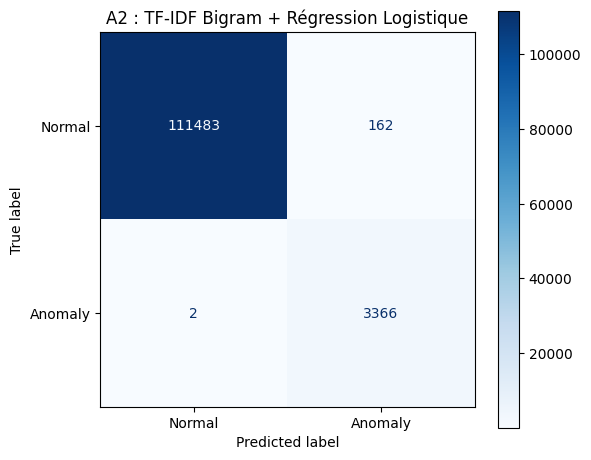

In [9]:
# Matrice de confusion — A2
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_a2,
    display_labels=['Normal', 'Anomaly'],
    cmap='Blues', ax=ax
)
ax.set_title('A2 : TF-IDF Bigram + Régression Logistique')
plt.tight_layout()
plt.show()


### 2.3 Comparaison A1 vs A2


In [10]:
# Tableau récapitulatif Tier 1 (côté ML)
results_tier1_ml = {
    'Expérience': ['A1 (Unigram)', 'A2 (Bigram)'],
    'Precision': [
        precision_score(y_test, y_pred_a1),
        precision_score(y_test, y_pred_a2)
    ],
    'Recall': [
        recall_score(y_test, y_pred_a1),
        recall_score(y_test, y_pred_a2)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_a1),
        f1_score(y_test, y_pred_a2)
    ],
    'Temps entraînement (s)': [t_train_a1, t_train_a2],
    'Temps prédiction (s)': [t_pred_a1, t_pred_a2],
}

df_tier1_ml = pd.DataFrame(results_tier1_ml)
print("=== Résultats Tier 1 — Représentation Lexicale ===")
display(df_tier1_ml.round(4))


=== Résultats Tier 1 — Représentation Lexicale ===


,Expérience,Precision,Recall,F1-Score,Temps entraînement (s),Temps prédiction (s)
0,A1 (Unigram),0.9601,0.9994,0.9793,0.8100,0.0029
1,A2 (Bigram),0.9541,0.9994,0.9762,0.8741,0.0058


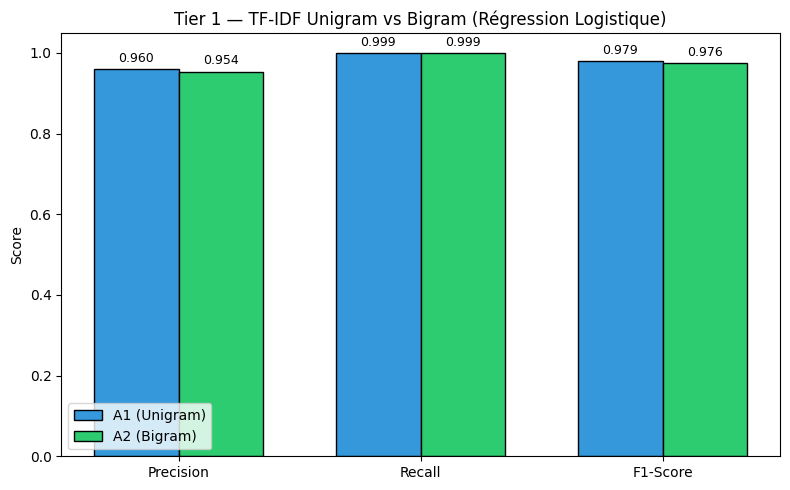

In [11]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.35

vals_a1 = [df_tier1_ml.iloc[0][m] for m in metrics]
vals_a2 = [df_tier1_ml.iloc[1][m] for m in metrics]

bars1 = ax.bar(x - width/2, vals_a1, width, label='A1 (Unigram)', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, vals_a2, width, label='A2 (Bigram)', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Tier 1 — TF-IDF Unigram vs Bigram (Régression Logistique)')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.05)

# Valeurs sur les barres
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


#### 3. Tier 2 — Scénario non supervisé (Isolation Forest)

In [12]:
from sklearn.ensemble import IsolationForest


if_c1 = IsolationForest(
    n_estimators=100,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

t_start = time.time()
if_c1.fit(X_train_uni)
t_train_c1 = time.time() - t_start

t_start = time.time()
y_pred_c1_raw = if_c1.predict(X_test_uni)
t_pred_c1 = time.time() - t_start

# Conversion : IF retourne -1 (anomalie) et 1 (normal)
y_pred_c1 = [1 if p == -1 else 0 for p in y_pred_c1_raw]

print("=== C1 : TF-IDF Unigram + Isolation Forest ===")
print(f"Temps d'entraînement : {t_train_c1:.2f}s")
print(f"Temps de prédiction  : {t_pred_c1:.4f}s")
print(f"\n{classification_report(y_test, y_pred_c1, target_names=['Normal', 'Anomaly'])}")


=== C1 : TF-IDF Unigram + Isolation Forest ===
Temps d'entraînement : 2.47s
Temps de prédiction  : 0.4333s

              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99    111645
     Anomaly       0.63      0.57      0.60      3368

    accuracy                           0.98    115013
   macro avg       0.81      0.78      0.79    115013
weighted avg       0.98      0.98      0.98    115013



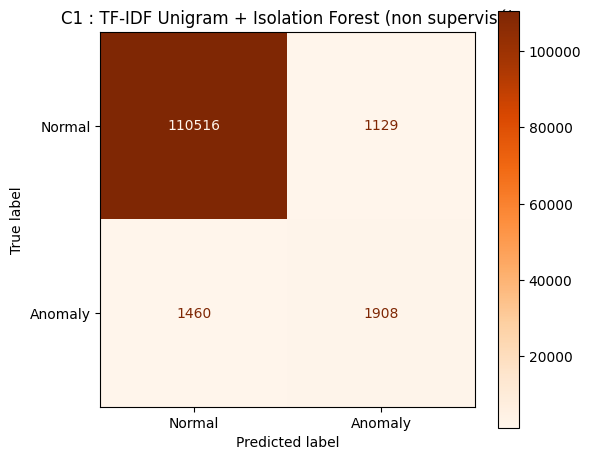

In [13]:
# Matrice de confusion — C1
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_c1,
    display_labels=['Normal', 'Anomaly'],
    cmap='Oranges', ax=ax
)
ax.set_title('C1 : TF-IDF Unigram + Isolation Forest (non supervisé)')
plt.tight_layout()
plt.show()


#### 4. Tier 3 — Meilleure performance (Best Effort)

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

t_start = time.time()
rf.fit(X_train_uni, y_train)
t_train_rf = time.time() - t_start

t_start = time.time()
y_pred_rf = rf.predict(X_test_uni)
t_pred_rf = time.time() - t_start

print("=== Tier 3 : TF-IDF Unigram + Random Forest ===")
print(f"Temps d'entraînement : {t_train_rf:.2f}s")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Normal', 'Anomaly'])}")


=== Tier 3 : TF-IDF Unigram + Random Forest ===
Temps d'entraînement : 42.11s

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       1.00      1.00      1.00      3368

    accuracy                           1.00    115013
   macro avg       1.00      1.00      1.00    115013
weighted avg       1.00      1.00      1.00    115013



In [15]:
# Linear SVM
svm = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=2000
)

t_start = time.time()
svm.fit(X_train_uni, y_train)
t_train_svm = time.time() - t_start

t_start = time.time()
y_pred_svm = svm.predict(X_test_uni)
t_pred_svm = time.time() - t_start

print("=== Tier 3 : TF-IDF Unigram + Linear SVM ===")
print(f"Temps d'entraînement : {t_train_svm:.2f}s")
print(f"\n{classification_report(y_test, y_pred_svm, target_names=['Normal', 'Anomaly'])}")


=== Tier 3 : TF-IDF Unigram + Linear SVM ===
Temps d'entraînement : 51.12s

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       0.96      1.00      0.98      3368

    accuracy                           1.00    115013
   macro avg       0.98      1.00      0.99    115013
weighted avg       1.00      1.00      1.00    115013



## 5. Tableau récapitulatif — Tous les résultats ML


In [16]:
# Tableau complet de tous les résultats côté ML
all_results = {
    'Expérience': [
        'A1 — TF-IDF Uni + LR',
        'A2 — TF-IDF Bi + LR',
        'C1 — TF-IDF Uni + IF',
        'T3 — TF-IDF Uni + RF',
        'T3 — TF-IDF Uni + SVM',
    ],
    'Tier': ['Tier 1', 'Tier 1', 'Tier 2', 'Tier 3', 'Tier 3'],
    'Supervisé': ['Oui', 'Oui', 'Non', 'Oui', 'Oui'],
    'Precision': [
        precision_score(y_test, y_pred_a1),
        precision_score(y_test, y_pred_a2),
        precision_score(y_test, y_pred_c1),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm),
    ],
    'Recall': [
        recall_score(y_test, y_pred_a1),
        recall_score(y_test, y_pred_a2),
        recall_score(y_test, y_pred_c1),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm),
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_a1),
        f1_score(y_test, y_pred_a2),
        f1_score(y_test, y_pred_c1),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm),
    ],
}

df_all = pd.DataFrame(all_results)
print("=" * 75)
print("RÉSULTATS COMPLETS — PIPELINE ML (Représentation Lexicale)")
print("=" * 75)
display(df_all.round(4))


RÉSULTATS COMPLETS — PIPELINE ML (Représentation Lexicale)


,Expérience,Tier,Supervisé,Precision,Recall,F1-Score
0,A1 — TF-IDF Uni + LR,Tier 1,Oui,0.9601,0.9994,0.9793
1,A2 — TF-IDF Bi + LR,Tier 1,Oui,0.9541,0.9994,0.9762
2,C1 — TF-IDF Uni + IF,Tier 2,Non,0.6283,0.5665,0.5958
3,T3 — TF-IDF Uni + RF,Tier 3,Oui,0.9985,0.9991,0.9988
4,T3 — TF-IDF Uni + SVM,Tier 3,Oui,0.9645,0.9997,0.9818


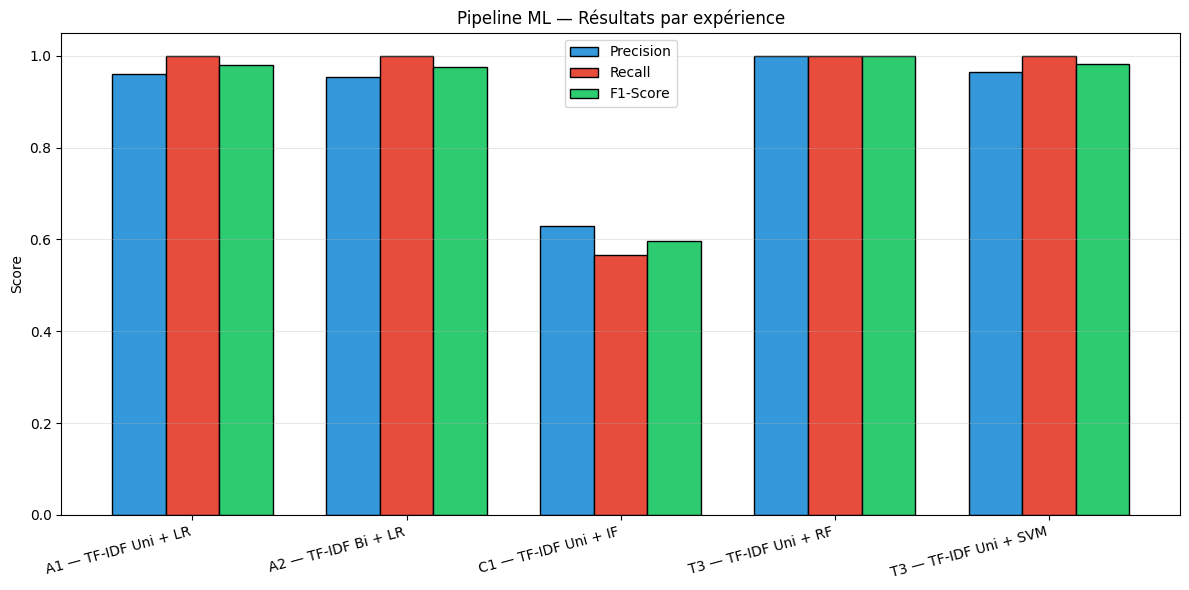

In [17]:
# Visualisation comparative de tous les modèles
fig, ax = plt.subplots(figsize=(12, 6))

experiments = df_all['Expérience']
x = np.arange(len(experiments))
width = 0.25

ax.bar(x - width, df_all['Precision'], width, label='Precision', color='#3498db', edgecolor='black')
ax.bar(x, df_all['Recall'], width, label='Recall', color='#e74c3c', edgecolor='black')
ax.bar(x + width, df_all['F1-Score'], width, label='F1-Score', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Pipeline ML — Résultats par expérience')
ax.set_xticks(x)
ax.set_xticklabels(experiments, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "all_ml_results.png"))
plt.show()


## 6. Analyse des erreurs (Tier 1 — A1)
Identification et examen des **faux négatifs** (anomalies manquées) et **faux positifs** (fausses alertes).  
Cette analyse est cruciale pour comprendre les limites de la représentation lexicale et préparer la comparaison avec le pipeline LLM.


In [18]:
# Identification des erreurs du modèle A1
test_block_ids = [block_ids[i] for i in test_idx]

# Faux négatifs : anomalies réelles que le modèle a manquées
fn_indices = [i for i, (yt, yp) in enumerate(zip(y_test, y_pred_a1)) if yt == 1 and yp == 0]
fn_block_ids = [test_block_ids[i] for i in fn_indices]

# Faux positifs : sessions normales prédites comme anomalies
fp_indices = [i for i, (yt, yp) in enumerate(zip(y_test, y_pred_a1)) if yt == 0 and yp == 1]
fp_block_ids = [test_block_ids[i] for i in fp_indices]

# Vrais positifs : anomalies correctement détectées
tp_indices = [i for i, (yt, yp) in enumerate(zip(y_test, y_pred_a1)) if yt == 1 and yp == 1]

print(f"Anomalies dans le test set :    {sum(y_test):,}")
print(f"Vrais positifs (détectées) :    {len(tp_indices):,}")
print(f"Faux négatifs (manquées) :      {len(fn_indices):,}")
print(f"Faux positifs (fausses alertes) : {len(fp_indices):,}")


Anomalies dans le test set :    3,368
Vrais positifs (détectées) :    3,366
Faux négatifs (manquées) :      2
Faux positifs (fausses alertes) : 140


In [19]:
# Examen détaillé des faux négatifs (anomalies manquées par TF-IDF)
print("=" * 75)
print("FAUX NÉGATIFS — Anomalies manquées par TF-IDF + LR")
print("=" * 75)
print()

for bid in fn_block_ids[:5]:
    s = enriched_sessions[bid]
    print(f" {bid}  [{len(s['events'])} événements]")
    print(f" Séquence : {s['sequence_str']}")
    print()


FAUX NÉGATIFS — Anomalies manquées par TF-IDF + LR

 blk_2429961036831384938  [15 événements]
 Séquence : E2 E1 E1 E1 E3 E4 E5 E12 E11 E3 E4 E3 E4 E5 E5

 blk_-1791865405548036877  [15 événements]
 Séquence : E1 E2 E1 E1 E3 E4 E5 E3 E4 E3 E4 E5 E11 E12 E5



In [20]:
# Comparaison des motifs : Faux négatif / vrai positif 
fn_sequences = [enriched_sessions[bid]['sequence_str'] for bid in fn_block_ids]
tp_sequences = [enriched_sessions[bid]['sequence_str'] for bid in [test_block_ids[i] for i in tp_indices]]

fn_patterns = Counter(fn_sequences)
tp_patterns = Counter(tp_sequences)

print("--- Motifs fréquents dans les faux négatifs (anomalies manquées) ---")
for pattern, count in fn_patterns.most_common(5):
    print(f"  [{count:>4}x] {pattern}")

print(f"\n--- Motifs fréquents dans les vrais positifs (anomalies détectées) ---")
for pattern, count in tp_patterns.most_common(5):
    print(f"  [{count:>4}x] {pattern}")

--- Motifs fréquents dans les faux négatifs (anomalies manquées) ---
  [   1x] E2 E1 E1 E1 E3 E4 E5 E12 E11 E3 E4 E3 E4 E5 E5
  [   1x] E1 E2 E1 E1 E3 E4 E5 E3 E4 E3 E4 E5 E11 E12 E5

--- Motifs fréquents dans les vrais positifs (anomalies détectées) ---
  [ 335x] E1 E2
  [ 272x] E1 E1 E2 E16
  [ 258x] E2 E1 E1 E16
  [ 249x] E2 E1
  [ 115x] E1 E2 E1 E16


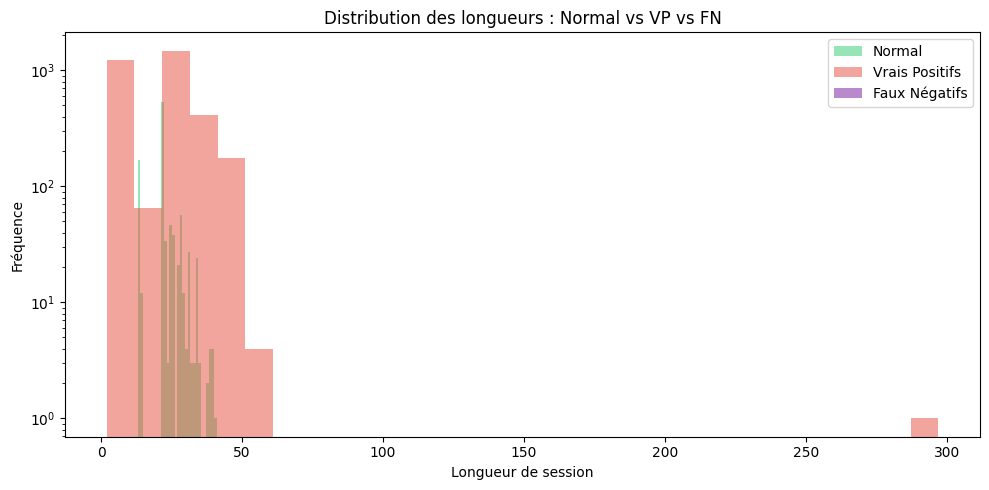

Longueur moyenne — Normal: 22.1, VP: 19.3, FN: 15.0


In [21]:
fn_lens = [len(enriched_sessions[bid]['events']) for bid in fn_block_ids]
tp_lens = [len(enriched_sessions[bid]['events']) for bid in [test_block_ids[i] for i in tp_indices]]
normal_test_ids = [test_block_ids[i] for i, yt in enumerate(y_test) if yt == 0]
normal_lens = [len(enriched_sessions[bid]['events']) for bid in normal_test_ids[:1000]]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(normal_lens, bins=30, alpha=0.5, label='Normal', color='#2ecc71')
ax.hist(tp_lens, bins=30, alpha=0.5, label='Vrais Positifs', color='#e74c3c')
ax.hist(fn_lens, bins=30, alpha=0.7, label='Faux Négatifs', color='#9b59b6')
ax.set_xlabel('Longueur de session')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des longueurs : Normal vs VP vs FN')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fn_length_analysis.png"))
plt.show()

print(f"Longueur moyenne — Normal: {np.mean(normal_lens):.1f}, VP: {np.mean(tp_lens):.1f}, FN: {np.mean(fn_lens):.1f}")


## 7. Sauvegarde des résultats et des prédictions


In [27]:
# Sauvegarde des résultats pour comparaison avec le pipeline LLM
ml_results = {
    'y_test': y_test,
    'y_pred_a1': y_pred_a1,
    'y_pred_a2': y_pred_a2,
    'y_pred_c1': y_pred_c1,
    'y_pred_rf': y_pred_rf,
    'y_pred_svm': y_pred_svm,
    'test_block_ids': test_block_ids,
    'fn_block_ids_a1': fn_block_ids,
    'fp_block_ids_a1': fp_block_ids,
    'tfidf_vectorizer_uni': tfidf_uni,
    'tfidf_vectorizer_bi': tfidf_bi,
    'X_train_uni': X_train_uni,
    'X_test_uni': X_test_uni,
    'X_train_bi': X_train_bi,
    'X_test_bi': X_test_bi,
    'times': {
        'tfidf_uni': t_tfidf_uni,
        'tfidf_bi': t_tfidf_bi,
        'train_a1': t_train_a1,
        'train_a2': t_train_a2,
        'train_c1': t_train_c1,
        'pred_a1': t_pred_a1,
        'pred_a2': t_pred_a2,
        'pred_c1': t_pred_c1,
    }
}

with open(os.path.join(OUTPUT_DIR, "ml_results.pkl"), 'wb') as f:
    pickle.dump(ml_results, f)

# Sauvegarde du tableau de résultats en CSV
df_all.to_csv(os.path.join(OUTPUT_DIR, "ml_results_table.csv"), index=False)
